# 13c — Reinders Credit-Transition Mark-to-Market Loss Model

Covers `chap13_credit8a-8d`: the Reinders et al. equity+debt
mark-to-market loss under an instantaneous asset-value haircut
`A(t)=A0*(1-xi)`, weighted by an investor's equity/debt holding shares
`omega_E`/`omega_D` — self-verified against a numerical-differentiation
cross-check, then plotted (loss, first derivative, second derivative)
across 4 `(omega_E, omega_D)` scenarios.

**Function-availability note:** `Reinders_Credit_Model.m` is absent from
this `hfs-archive` checkout, but is already ported and installed as
`quanttoolbox.credit.structural.reinders_credit_model` — with one
disclosed translation decision already documented in its own docstring:
the original MATLAB function accepts a `mu_A` parameter that is never
used anywhere in its formula body (no documented reason), so the Python
port drops it from the signature entirely (call sites below skip it,
matching the port's 8-argument signature rather than the MATLAB
original's 9-argument one). `numerical_gradient`/`numerical_hessian` are
found directly in `QuantToolbox/maths/` and already ported as
`quanttoolbox.maths.numerical_diff.{numerical_gradient,numerical_hessian}`.

**Notebook structure note:** `credit8b`/`8c`/`8d` are byte-for-byte
identical setups (same parameters, same `Reinders_Credit_Model` call)
that only differ in which of the 3 output columns (`Loss`, `D_Loss`,
`D2_Loss`) they plot — collapsed here into one shared computation
followed by 3 plot cells, rather than tripling the setup code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from quanttoolbox.credit.structural import reinders_credit_model
from quanttoolbox.maths.numerical_diff import numerical_gradient, numerical_hessian

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"

plt.rcParams["figure.dpi"] = 100


## 1. Self-verification: numerical vs. analytic loss gradient/Hessian (`chap13_credit8a`)

At each `xi` on a `0.00:0.05:0.99` grid, `Reinders_Credit_Model`'s
analytic `D_Loss`/`D2_Loss` are compared against a numerical
gradient/Hessian applied to the underlying plain-Merton equity/debt
value formulas (`Merton_MV_E`, `Merton_MV_D`, local functions in the
source file, reproduced below), and against the *further* closed-form
first derivative of those same formulas (`g2_E`, `g2_D`, via
`-A0*normcdf(d1)`/`-A0*normcdf(-d1)`) — three independent routes to the
same underlying quantity.

In [2]:
A0, D, r, mu_A, sigma_A, T = 25, 20, 0.03, 0.05, 0.10, 10
omega_E, omega_D = 0.10, 0.20


def merton_mv_e(xi):
    xi = float(np.asarray(xi).item())
    A_t = A0 * (1 - xi)
    d1 = (np.log(A_t / D) + r * T) / (sigma_A * np.sqrt(T)) + 0.5 * sigma_A * np.sqrt(T)
    d2 = d1 - sigma_A * np.sqrt(T)
    return A_t * norm.cdf(d1) - D * np.exp(-r * T) * norm.cdf(d2)


def merton_mv_d(xi):
    xi = float(np.asarray(xi).item())
    A_t = A0 * (1 - xi)
    d1 = (np.log(A_t / D) + r * T) / (sigma_A * np.sqrt(T)) + 0.5 * sigma_A * np.sqrt(T)
    d2 = d1 - sigma_A * np.sqrt(T)
    return A_t * norm.cdf(-d1) + D * np.exp(-r * T) * norm.cdf(d2)


rows = []
for xi in np.arange(0.00, 0.991, 0.05):
    g1_E = numerical_gradient(merton_mv_e, np.array([xi]))[0]
    g1_D = numerical_gradient(merton_mv_d, np.array([xi]))[0]
    A_t = A0 * (1 - xi)
    d1 = (np.log(A_t / D) + r * T) / (sigma_A * np.sqrt(T)) + 0.5 * sigma_A * np.sqrt(T)
    g2_E = -A0 * norm.cdf(d1)
    g2_D = -A0 * norm.cdf(-d1)
    grd_Loss = -omega_E * g1_E - omega_D * g1_D
    h1_E = numerical_hessian(merton_mv_e, np.array([xi]))[0, 0]
    h1_D = numerical_hessian(merton_mv_d, np.array([xi]))[0, 0]
    hss_Loss = -omega_E * h1_E - omega_D * h1_D
    res = reinders_credit_model(xi, A0, D, r, sigma_A, T, omega_E, omega_D)
    rows.append([xi, g1_E, g2_E, g1_D, g2_D, grd_Loss, res.d_loss, hss_Loss, res.d2_loss])

cols8a = ["xi", "g1_E (num)", "g2_E (analytic)", "g1_D (num)", "g2_D (analytic)",
          "grd_Loss (num)", "D_Loss (model)", "hss_Loss (num)", "D2_Loss (model)"]
display(pd.DataFrame(rows, columns=cols8a).round(4))


,xi,g1_E (num),g2_E (analytic),g1_D (num),g2_D (analytic),grd_Loss (num),D_Loss (model),hss_Loss (num),D2_Loss (model)
0,0.00,-24.1260,-24.1260,-0.8740,-0.8740,2.5874,2.5874,0.6104,0.6103
1,0.05,-23.7638,-23.7638,-1.2362,-1.2362,2.6236,2.6236,0.8508,0.8507
2,0.10,-23.2616,-23.2616,-1.7384,-1.7384,2.6738,2.6738,1.1734,1.1734
3,0.15,-22.5736,-22.5736,-2.4264,-2.4264,2.7426,2.7426,1.5970,1.5970
4,0.20,-21.6452,-21.6452,-3.3548,-3.3548,2.8355,2.8355,2.1369,2.1368
5,0.25,-20.4165,-20.4165,-4.5835,-4.5835,2.9584,2.9584,2.7982,2.7979
6,0.30,-18.8295,-18.8295,-6.1705,-6.1705,3.1170,3.1170,3.5648,3.5645
7,0.35,-16.8428,-16.8428,-8.1572,-8.1572,3.3157,3.3157,4.3849,4.3846
8,0.40,-14.4528,-14.4528,-10.5472,-10.5472,3.5547,3.5547,5.1558,5.1554
9,0.45,-11.7220,-11.7220,-13.2780,-13.2780,3.8278,3.8278,5.7171,5.7169


## 2. Loss, first derivative, and second derivative vs. haircut (`chap13_credit8b-8d`)

`Reinders_Credit_Model`'s portfolio loss `L(xi)` (and its 1st/2nd
derivatives) plotted vs. haircut `xi` (0-99.9%), for 4 `(omega_E,
omega_D)` equity/debt-weight combinations.

In [3]:
xi_t = np.concatenate([[0.0], np.arange(0.01, 0.9901, 0.01), [0.999]])
omega_E_v = np.array([0.10, 0.20, 0.50, 0.90])
omega_D_v = np.array([0.30, 0.70, 0.30, 0.10])

res8 = reinders_credit_model(xi_t[:, None], A0, D, r, sigma_A, T, omega_E_v[None, :], omega_D_v[None, :])

styles = ["-", "--", ":", "-."]
colors8 = [color_blue, color_red, color_green, color_violet]
widths8 = [1.5, 1.5, 2.0, 1.5]
labels8 = [rf"$\omega_E={omega_E_v[i]:.2f}$, $\omega_D={omega_D_v[i]:.2f}$" for i in range(4)]


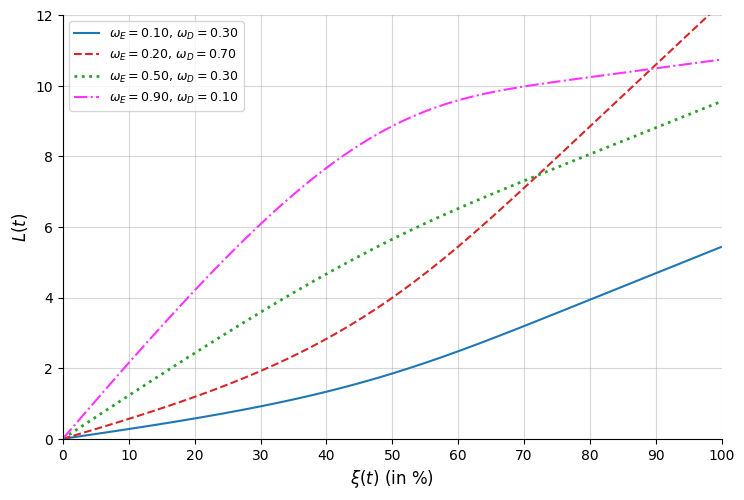

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i in range(4):
    ax.plot(100 * xi_t, res8.loss[:, i], styles[i], color=colors8[i], linewidth=widths8[i], label=labels8[i])

ax.set_xlabel(r"$\xi(t)$ (in %)", fontsize=12)
ax.set_ylabel(r"$L(t)$", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_ylim(0, 12)
ax.set_yticks(range(0, 13, 2))
plt.show()


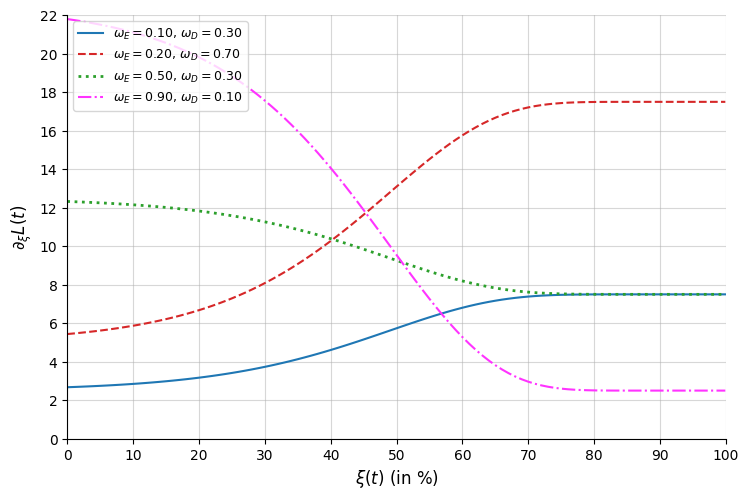

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i in range(4):
    ax.plot(100 * xi_t, res8.d_loss[:, i], styles[i], color=colors8[i], linewidth=widths8[i], label=labels8[i])

ax.set_xlabel(r"$\xi(t)$ (in %)", fontsize=12)
ax.set_ylabel(r"$\partial_{\xi}L(t)$", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_ylim(0, 22)
ax.set_yticks(range(0, 23, 2))
plt.show()


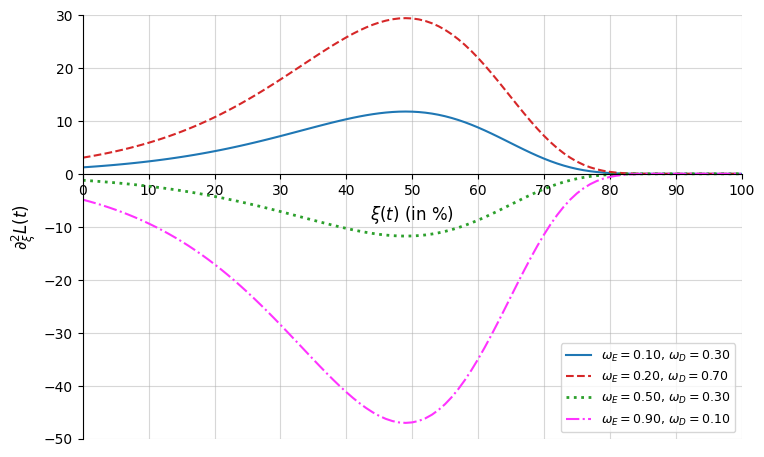

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for i in range(4):
    ax.plot(100 * xi_t, res8.d2_loss[:, i], styles[i], color=colors8[i], linewidth=widths8[i], label=labels8[i])

ax.set_xlabel(r"$\xi(t)$ (in %)", fontsize=12)
ax.set_ylabel(r"$\partial^{2}_{\xi}L(t)$", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_position("zero")
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_ylim(-50, 30)
ax.set_yticks(range(-50, 31, 10))
plt.show()
